<a href="https://colab.research.google.com/github/Pete-Reseacher/python-geoscience/blob/main/Peter_obiefuna_WK2_Visualization_Exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises 2

<p>This is an exercise to test your understanding of Python Visualizations.</p>

___
## &copy; Levi Daniel
___

#### 1. You are given the following data in the code cell.
Tasks:
* Plot Porosity vs Depth using A line plot
* Format the plot: Invert the depth axis, Add grid, Add title, Label both axes properly
* Change: Line color, Marker style, Line width

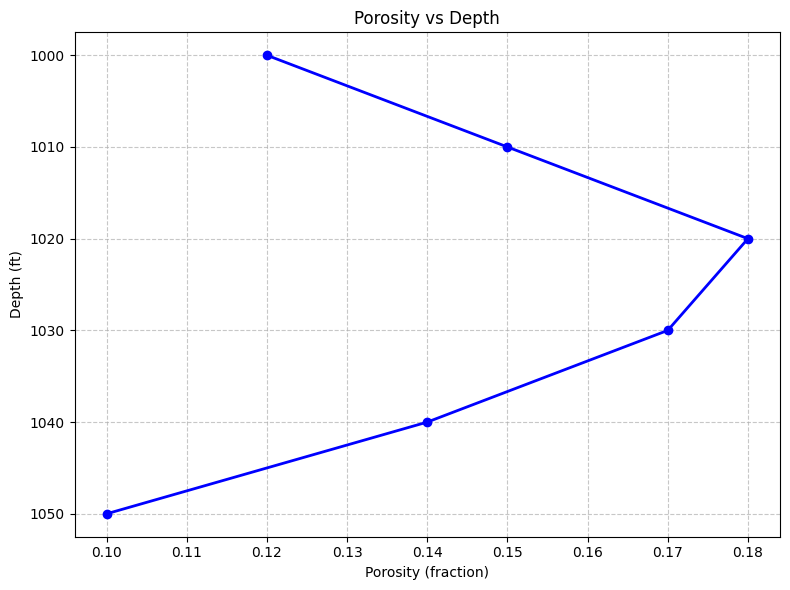

In [ ]:
depth = [1000, 1010, 1020, 1030, 1040, 1050]
porosity = [0.12, 0.15, 0.18, 0.17, 0.14, 0.10]

# Your code goes here
import matplotlib.pyplot as plt

# Given data
Depth = [1000, 1010, 1020, 1030, 1040, 1050]
Porosity = [0.12, 0.15, 0.18, 0.17, 0.14, 0.10]

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(Porosity, Depth, color ='blue',  marker='o', linestyle='-', linewidth=2,  markersize=6)


# invert the depth axis
plt.gca().invert_yaxis()

# Add title and labels
plt.title('Porosity vs Depth')
plt.xlabel('Porosity (fraction)')
plt.ylabel('Depth (ft)')

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# show the plot
plt.tight_layout()
plt.show()

#### 2. You are given permeability data (mD).

Tasks:
* Create A seaborn bar plot of permeability vs sample index, and A histogram showing permeability distribution.
* Format properly: Proper axis labels, Professional title, Clean grid style
* Based on the histogram: Is the distribution skewed?, What type of reservoir might this represent?

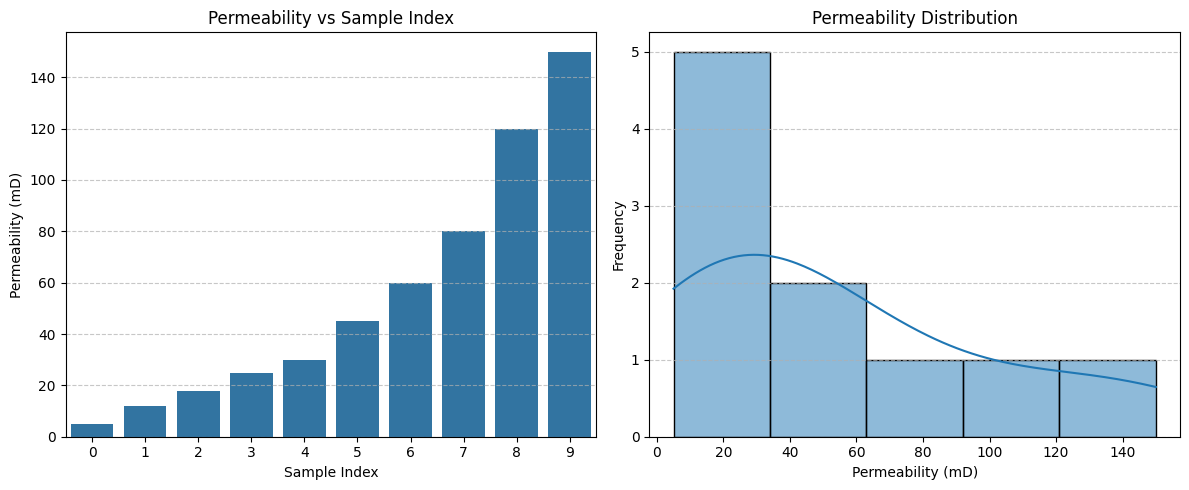

In [ ]:
perm = [5, 12, 18, 25, 30, 45, 60, 80, 120, 150]

# Your code goes here:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Given Permeability data
Permeability = [5, 12, 18, 25, 30, 45, 60, 80, 120, 150]

# Create a DataFrame
df = pd.DataFrame({'Permeability (mD)': Permeability})

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
sns.barplot(x=df.index, y=df['Permeability (mD)'], ax=ax[0])
ax[0].set_title('Permeability vs Sample Index')
ax[0].set_xlabel('Sample Index')
ax[0].set_ylabel('Permeability (mD)')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram
sns.histplot(df['Permeability (mD)'], ax=ax[1], kde=True)
ax[1].set_title('Permeability Distribution')
ax[1].set_xlabel('Permeability (mD)')
ax[1].set_ylabel('Frequency')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

##### Write your interpretation here...
Text here:

#### 3. Load in the Well1_MICP.csv dataset

Tasks:
* Perform basic EDA: display First 5 rows, Column names, Summary statistics, Check for missing values.
* Plot Capillary Pressure (Pc) vs Water Saturation (Sw)
* Format properly: Proper axis labels, Grid, Clean formatting
* Identify from the plot: Entry pressure and Approximate irreducible water saturation (Swirr)

First few rows:
  Well_Name     DEPTH   CPHI      PC_Lab CShg CPERM  SampleID    CDEPTH
0       NaN        ft    v/v         bar  v/v    mD  unitless        ft
1     Well1  7627.606  0.249  0.06894757    0   136        10  7629.606
2     Well1  7627.606  0.249   0.1378951    0   136        10  7629.606
3     Well1  7627.606  0.249   0.2068427    0   136        10  7629.606
4     Well1  7627.606  0.249   0.4136854    0   136        10  7629.606

Columns names:
Index(['Well_Name', 'DEPTH', 'CPHI', 'PC_Lab', 'CShg', 'CPERM', 'SampleID',
       'CDEPTH'],
      dtype='object')

Summary statistics:
       Well_Name     DEPTH   CPHI PC_Lab   CShg CPERM SampleID    CDEPTH
count        552       553    553    553    553   553      553       553
unique         1         9      9     27    139     9        9         9
top        Well1  7627.606  0.249  -9999  -9999   136       10  7629.606
freq         552        69     69    352    352    69       69        69

Missing values:
Well_Name    1
DE

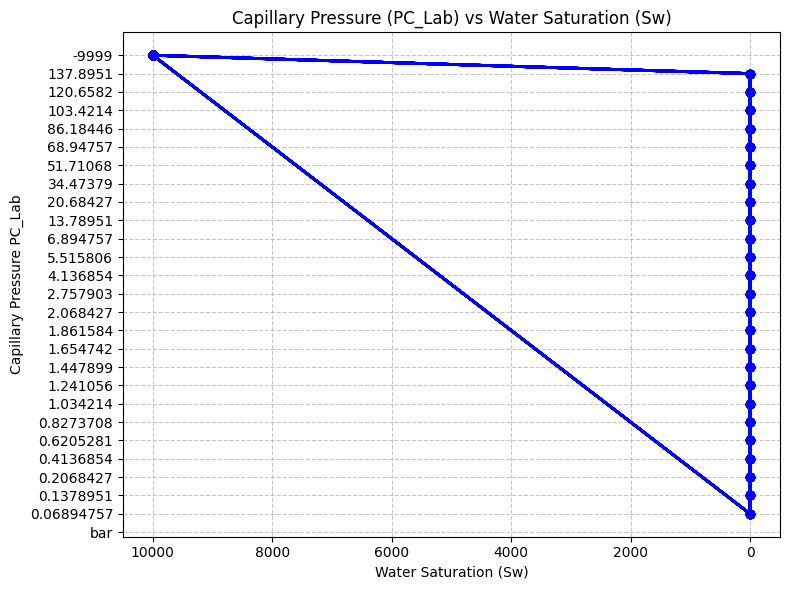

Estimated Swir: 0.04


In [12]:
# Your code goes here:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Well1_MICP.csv')

# Basic EDA
print("First few rows:")
print(df.head())
print("\nColumns names:")
print(df.columns)
print("\nSummary statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

# calculate Sw from CShg,first i convert the -9999 to NAN
df['CShg'] = pd.to_numeric(df['CShg'], errors='coerce')
df['Sw'] = 1 - df['CShg']


# Plot Capillary pressure (Pc) vs water saturation (Sw)
plt.figure(figsize=(8, 6))
plt.plot(df['Sw'], df['PC_Lab'],
          color='blue',
          marker='o',
          linestyle='-',
          linewidth=2,
          markersize=6)


# Format the plot
plt.title('Capillary Pressure (PC_Lab) vs Water Saturation (Sw)')
plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Capillary Pressure PC_Lab')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().invert_xaxis()  # Sw typically decreases
plt.tight_layout()
plt.show()

# Estimate Swir (irreducible water saturation)
Swir_estimate = df['Sw'].min()
print(f'Estimated Swir: {Swir_estimate:.2f}')



# INTERPRETATION OF THE GRAPH.
Text here:
#The graph shows Capillary Pressure(PC_Lab) VS Water Saturation(Sw)
 # In simple terms:
X- axis(Sw): Water saturation in the rock(0-1 or 0-100%). 1 mean fully water-saturation,0 means no water.

Y-axis(PC_Lab):Pressure needed to push water out of the rock.

The curve typically:
Starts high on the left(low Sw,High PC):
Hard to push water out when there's little water left.

Goes down as Sw increases: Easier to push water out when there's more water.

The graph helps understand how much water is trapped in the rock at different pressures.
